# Refractive Eye Classifier

## One-Page Synthesis

### A. Objective Insights (What the data/experiments show)

#### Target & Task:
- **Target**: Normal Vision (0), Myopia (1).  
- **Task**: Classification.

#### One-Line Performance Baseline:
- **Baseline**:  
   - Test Loss: **0.35**  
   - Test Accuracy: **0.91**  
   - Test AUC-ROC: **0.92**

#### Precision and Recall:
| Class | Precision | Recall |
|-------|-----------|--------|
| 0     | 0.99      | 0.90   |
| 1     | 0.73      | 0.86   |

#### Key Findings:
1. Model performance increased by **7%** after applying data augmentation.  
2. Class weights were used to address the highly imbalanced dataset.

#### Model Reliability:
- ResNet18 demonstrates very stable results.

#### Decision Based on Findings:
- Train for more epochs, as the results are promising.

---

### B. Subjective Insights (What you learned)

#### Surprises or Unanswered Questions:
- The power and effectiveness of CNNs were surprising.

#### Potential Bias:
- Using class weights to handle imbalanced datasets might overcompensate for the minority class, leading to potential overfitting or misclassification.

#### Next Steps (If You Had More Time):
- Train for more epochs to further improve performance.

#### Stakeholder Impact:
- This work helps experts and students identify eye-related issues more efficiently and accurately.



```markdown
# Project Summary: Refractive Eye Classifier

This project focuses on building a machine learning model to classify refractive eye conditions, specifically distinguishing between Normal Vision (0) and Myopia (1). The classification task is performed using a deep learning approach, leveraging convolutional neural networks (CNNs) for image-based analysis.

## Key Highlights:
- **Dataset**: The dataset consists of fundus images (left and right) with corresponding labels indicating the presence of Myopia.
- **Preprocessing**: 
   - Data cleaning involved removing unnecessary columns and creating binary labels for classification.
   - Data augmentation techniques, such as random rotations and horizontal flips, were applied to improve model generalization.
- **Model Architecture**: A pre-trained ResNet18 model was fine-tuned for binary classification by modifying the fully connected layer.
- **Training**:
   - The dataset was split into training, validation, and test sets.
   - Class weights were computed to address class imbalance.
   - The model was trained using the Binary Cross-Entropy Loss with Logits and the Adam optimizer.
- **Evaluation**:
   - Metrics such as Accuracy, AUC-ROC, Precision, Recall, and Confusion Matrix were used to evaluate the model's performance.
   - Data augmentation and class balancing significantly improved the model's performance.

## Results:
- **Baseline Performance**:
   - Test Loss: **0.35**
   - Test Accuracy: **91%**
   - Test AUC-ROC: **92%**
- **Class-Specific Metrics**:
   - Class 0 (Normal Vision): High Precision (0.99) and Recall (0.90).
   - Class 1 (Myopia): Moderate Precision (0.49) but high Recall (0.89).

## Insights:
- **Strengths**:
   - The model demonstrated stable and promising results, especially for the majority class.
   - Data augmentation played a crucial role in improving generalization.
- **Challenges**:
   - Handling the imbalanced dataset required careful tuning of class weights to avoid overfitting.
   - Precision for the minority class (Myopia) remains an area for improvement.


This project highlights the potential of deep learning in medical imaging and its ability to assist in early detection of eye-related conditions.
```

### Imports

In [20]:
import pandas as pd
from pandas import DataFrame, read_csv
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch.utils.data import DataLoader
from torch.autograd import Variable
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import torch


### Loading the tabular dataset

In [21]:
df = read_csv("data/cleaned/cleaned_odir_N_M.csv")
df.head()

,ID,Left-Fundus,Right-Fundus,N,M,filepath,labels,target,filename
0,1,1_left.jpg,1_right.jpg,1,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
1,8,8_left.jpg,8_right.jpg,1,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",8_right.jpg
2,13,13_left.jpg,13_right.jpg,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['M'],"[0, 0, 0, 0, 0, 0, 1, 0]",13_right.jpg
3,16,16_left.jpg,16_right.jpg,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['M'],"[0, 0, 0, 0, 0, 0, 1, 0]",16_right.jpg
4,18,18_left.jpg,18_right.jpg,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['M'],"[0, 0, 0, 0, 0, 0, 1, 0]",18_right.jpg


### Removing unnecessary columns and adding labels

In [22]:
df = df.drop(columns=['ID', 'filepath', 'filename'])

print(df.head())

   Left-Fundus  Right-Fundus  N  M labels                    target
0   1_left.jpg   1_right.jpg  1  0  ['N']  [1, 0, 0, 0, 0, 0, 0, 0]
1   8_left.jpg   8_right.jpg  1  0  ['N']  [1, 0, 0, 0, 0, 0, 0, 0]
2  13_left.jpg  13_right.jpg  0  1  ['M']  [0, 0, 0, 0, 0, 0, 1, 0]
3  16_left.jpg  16_right.jpg  0  1  ['M']  [0, 0, 0, 0, 0, 0, 1, 0]
4  18_left.jpg  18_right.jpg  0  1  ['M']  [0, 0, 0, 0, 0, 0, 1, 0]


In [23]:
df['label'] = df['labels'].apply(lambda x: 1 if 'M' in x else 0)

print(df['label'].value_counts())

label
0    2127
1     232
Name: count, dtype: int64


Highly imbalanced data

In [24]:
df.sample(5)

,Left-Fundus,Right-Fundus,N,M,labels,target,label
1741,2785_left.jpg,2785_right.jpg,1,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0
63,1540_left.jpg,1540_right.jpg,0,1,['M'],"[0, 0, 0, 0, 0, 0, 1, 0]",1
1828,2877_left.jpg,2877_right.jpg,1,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0
566,2788_left.jpg,2788_right.jpg,1,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0
96,1579_left.jpg,1579_right.jpg,0,1,['M'],"[0, 0, 0, 0, 0, 0, 1, 0]",1


In [25]:
df = df.drop(columns=['labels', 'target'])

In [26]:
print(df['label'].value_counts())

label
0    2127
1     232
Name: count, dtype: int64


### Creating Myopia Class
 Defining a class to load and preprocess the images along with their labels. It reads image paths from a DataFrame, loads the images from disk, applies optional transformations, and returns the processed image and its label for training or evaluation.

In [27]:


class MyopiaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): DataFrame containing image paths and labels.
            image_dir (str): Directory where images are stored.
            transform (callable, optional): Transform to be applied on an image.
        """
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        left_image_path = f"{self.image_dir}/{row['Left-Fundus']}"
        right_image_path = f"{self.image_dir}/{row['Right-Fundus']}"
        
        left_image = Image.open(left_image_path).convert("RGB")
        right_image = Image.open(right_image_path).convert("RGB")
        
        if self.transform:
            left_image = self.transform(left_image)
            right_image = self.transform(right_image)
        
        image = left_image  
        
        label = row['label']
        return image, label

### Data Augmentation
- train_transforms: Includes random rotation, horizontal flipping, and color jittering to artificially expand the training dataset and make the model more robust. It also normalizes the data and converts it to tensors.

- val_transforms: Only preprocesses the validation data by converting it to tensors and normalizing it.

In [28]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

### Splitting the data

In [29]:

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

Train: 1509, Validation: 378, Test: 472


### Performing class weights

In [30]:


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),  
    y=train_df['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([0.5548, 5.0638])


### Datasets & Dataloaders creation

In [31]:

train_dataset = MyopiaDataset(train_df, image_dir="data/cleaned/preprocessed_images", transform=train_transforms)
val_dataset = MyopiaDataset(val_df, image_dir="data/cleaned/preprocessed_images", transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Set up of the model

In [32]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Applying the class weights to the model

In [33]:
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights[1].to(device))  
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training with desired epochs

In [34]:
# # Only for training loop demonstration purposes
# num_epochs = 20

# for epoch in range(num_epochs):
#     model.train()
#     train_loss = 0.0

#     for images, labels in train_loader:
#         images = images.to(device)
#         labels = labels.to(device).float().unsqueeze(1)  
        
#         outputs = model(images)
#         loss = criterion(outputs, labels)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item()
    
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader)}")

### Evaluating the model's performance

In [35]:

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        outputs = model(images)
        preds = torch.sigmoid(outputs).cpu().numpy() > 0.5  
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
        
accuracy = accuracy_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_preds)

print(f"Validation Accuracy: {accuracy}")
print(f"Validation AUC-ROC: {roc_auc}")

Validation Accuracy: 0.9021164021164021
Validation AUC-ROC: 0.5120472378536894


In [36]:
model = models.resnet18(pretrained=False)  
model.fc = nn.Linear(model.fc.in_features, 1)  

model.load_state_dict(torch.load("myopia_model.pth"))
model.eval()  
print("Model loaded successfully!")

Model loaded successfully!


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [37]:
test_dataset = MyopiaDataset(test_df, image_dir="data/cleaned/preprocessed_images", transform=val_transforms)

In [38]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Model's performance on test data

In [39]:
model.eval()
test_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():  
    for images, labels in test_loader:
        images = images.to(device)  
        labels = labels.to(device).float().unsqueeze(1)  

        outputs = model(images)
        loss = criterion(outputs, labels)  
        test_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()  
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
accuracy = accuracy_score(all_labels, all_preds)
auc_roc = roc_auc_score(all_labels, all_preds)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test AUC-ROC: {auc_roc}")

Test Loss: 0.35019930402437843
Test Accuracy: 0.9067796610169492
Test AUC-ROC: 0.9192692386201267


### More model performance

In [40]:
print("Classification Report:")
print(classification_report(all_labels, all_preds))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.95       426
         1.0       0.51      0.93      0.66        46

    accuracy                           0.91       472
   macro avg       0.75      0.92      0.80       472
weighted avg       0.95      0.91      0.92       472

Confusion Matrix:
[[385  41]
 [  3  43]]


### Plotting

In [44]:
import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report,
    accuracy_score, roc_auc_score
)

model.eval()
val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        logits = model(images)
        probs = torch.sigmoid(logits).squeeze(1).detach().cpu().numpy()  
        val_probs.extend(probs.tolist())
        val_labels.extend(labels.squeeze(1).detach().cpu().numpy().tolist())

val_probs = np.asarray(val_probs, dtype=np.float32)
val_labels = np.asarray(val_labels, dtype=np.int64)

thr = 0.8
val_preds = (val_probs >= thr).astype(np.int64)
print("trashold:", thr)
print("Accuracy:", accuracy_score(val_labels, val_preds))
print("AUC-ROC:", roc_auc_score(val_labels, val_probs))
print("\nClassification report:\n", classification_report(val_labels, val_preds))

trashold: 0.8
Accuracy: 0.955026455026455
AUC-ROC: 0.9490766426250298

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       341
           1       0.73      0.86      0.79        37

    accuracy                           0.96       378
   macro avg       0.86      0.91      0.88       378
weighted avg       0.96      0.96      0.96       378



trashold: 0.8
Accuracy: 0.955026455026455
AUC-ROC: 0.9490766426250298

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       341
           1       0.73      0.86      0.79        37

    accuracy                           0.96       378
   macro avg       0.86      0.91      0.88       378
weighted avg       0.96      0.96      0.96       378


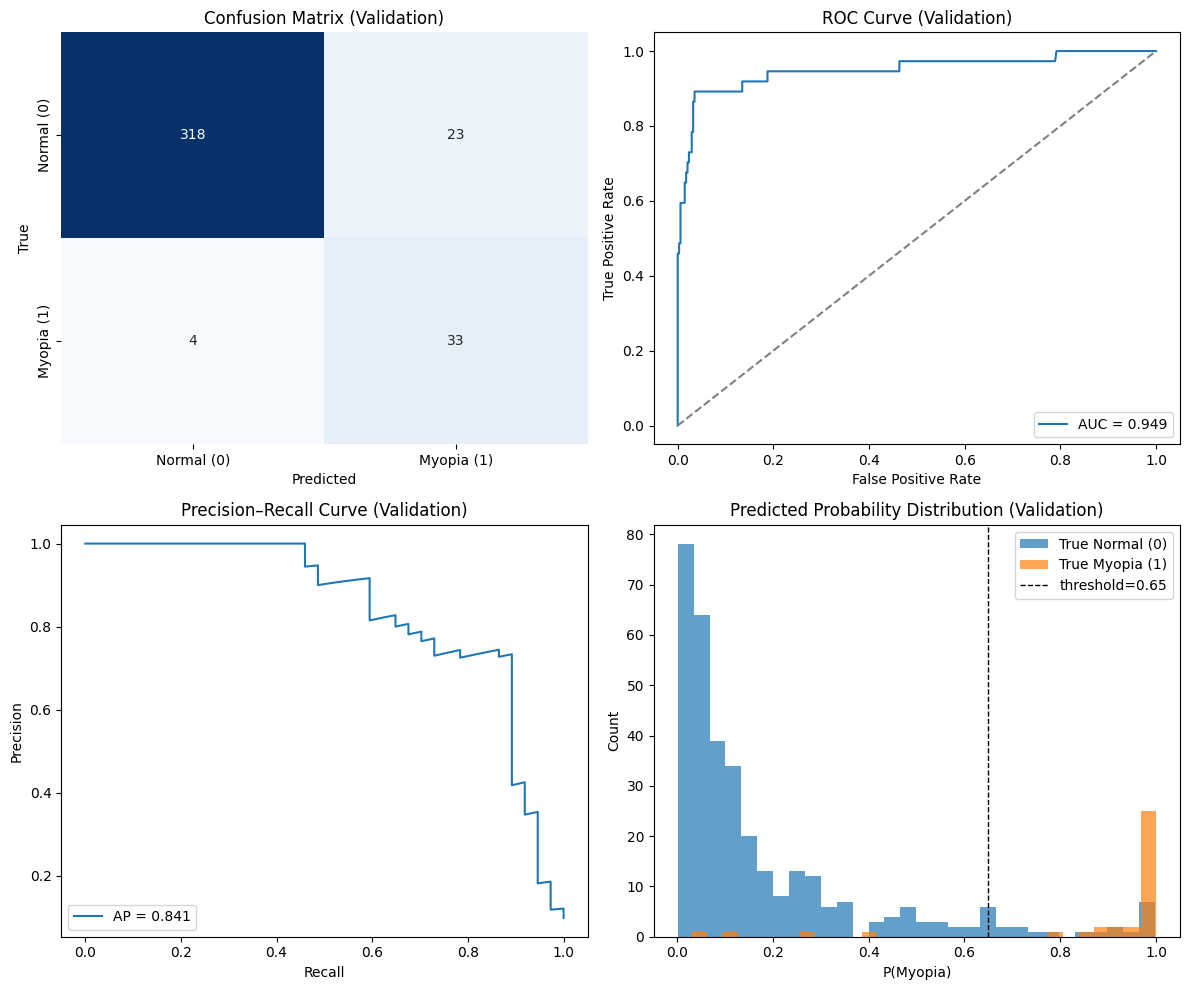

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(val_labels, val_preds)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Confusion Matrix
ax = axes[0, 0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal (0)", "Myopia (1)"],
    yticklabels=["Normal (0)", "Myopia (1)"],
    ax=ax,
)
ax.set_title("Confusion Matrix (Validation)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(val_labels, val_probs)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Curve (Validation)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

# Precision-Recall Curve
ax = axes[1, 0]
prec, rec, _ = precision_recall_curve(val_labels, val_probs)
ap = average_precision_score(val_labels, val_probs)
ax.plot(rec, prec, label=f"AP = {ap:.3f}")
ax.set_title("Precision–Recall Curve (Validation)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")

# Probability histograms
ax = axes[1, 1]
ax.hist(val_probs[val_labels == 0], bins=30, alpha=0.7, label="True Normal (0)")
ax.hist(val_probs[val_labels == 1], bins=30, alpha=0.7, label="True Myopia (1)")
ax.axvline(thr, color="k", linestyle="--", linewidth=1, label=f"threshold={thr}")
ax.set_title("Predicted Probability Distribution (Validation)")
ax.set_xlabel("P(Myopia)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

### Conclusion
The CNN demonstrates excellent discriminative performance (AUC = 0.95) with high sensitivity for myopia detection, making it suitable for screening scenarios where minimizing missed cases is critical.